In [1]:
import warnings
from datetime import date

import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

# Strategy parameters
UNIVERSE_SIZE = None  # None screens every current S&P 500 constituent returned by the source
FORMATION_MONTHS = 12
SKIP_MONTHS = 1
VOLATILITY_MONTHS = 12
MAX_WEIGHT = 0.12  # Maximum absolute weight per stock within either leg
N_LONG = 30
N_SHORT = 30
REBALANCE_FREQUENCY = "ME"
START_DATE = "2015-01-01"
END_DATE = date.today().isoformat()

print(
    f"Configured full S&P 500 universe, {N_LONG} long / {N_SHORT} short, "
    f"{REBALANCE_FREQUENCY} rebalance, rank-power {3.0:.1f} weights, "
    f"{MAX_WEIGHT:.1%} per-name cap"
)


Configured full S&P 500 universe, 30 long / 30 short, ME rebalance, rank-power 3.0 weights, 12.0% per-name cap


# Factor Risk Modeling: Investment Risk Handoff Report

## Executive Summary

This notebook builds and risk-manages a price-based momentum long-short portfolio using the current S&P 500 constituent universe. It is organized as a formal investment risk report:

1. Define the investable universe and construct the portfolio without look-ahead bias.
2. Measure portfolio performance against SPX.
3. Reconcile daily positions, weights, prices, and P&L for risk review.
4. Diagnose market and style-factor exposures using public proxies.
5. Test factor concentration, style drift, crowding proxies, covariance shifts, specific risk, validation, and stress scenarios.
6. Translate the risk diagnosis into drawdown de-risking actions and security-level review.

The final question is practical: **which risk should be reduced, from which positions, under which constraints, and with what impact on return, Sharpe, drawdown, and factor exposure?** The notebook provides diagnostics and transparent research proxies. It is not a licensed Barra model or an investment recommendation.

In [2]:
# 1) Build a reproducible equity universe from the public S&P 500 constituents page.
import requests
from io import StringIO

wiki_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
wiki_response = requests.get(
    wiki_url,
    headers={"User-Agent": "Mozilla/5.0 (research notebook; contact: analyst@example.com)"},
    timeout=30,
)
wiki_response.raise_for_status()
sp500 = pd.read_html(StringIO(wiki_response.text))[0]
tickers = (
    sp500["Symbol"]
    .str.replace(".", "-", regex=False)
    .drop_duplicates()
)
if UNIVERSE_SIZE is not None:
    tickers = tickers.head(UNIVERSE_SIZE)
tickers = tickers.tolist()

assert len(tickers) >= 500, f"Only found {len(tickers)} equities"
print(f"Universe: {len(tickers)} current S&P 500 constituents")
print(tickers[:10])

Universe: 503 current S&P 500 constituents
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [3]:
# 2) Download adjusted prices. auto_adjust=True makes returns split/dividend aware.
prices = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True,
)["Close"]

if isinstance(prices, pd.Series):
    prices = prices.to_frame()
prices = prices.dropna(axis=1, how="all").ffill(limit=5)

# Save the full constituent price history for later analysis.
prices.to_csv("sp500_constituent_prices.csv")

returns = prices.resample(REBALANCE_FREQUENCY).last().pct_change()
valid_tickers = returns.columns[returns.notna().sum() >= 24].tolist()
returns = returns[valid_tickers]
prices = prices[valid_tickers]
print(f"Price history available for {len(valid_tickers)} equities")

Price history available for 499 equities


## Daily Constituent Volume

Download daily trading volume for the same S&P 500 constituent universe used by the price history. The saved file supports liquidity, turnover, and capacity analysis without changing the return dataset.

In [4]:
# 3) Download and save daily trading volume for the constituent universe.
volume = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
    group_by="column",
    threads=True,
    )["Volume"]

if isinstance(volume, pd.Series):
    volume = volume.to_frame()
volume = volume.dropna(axis=1, how="all").reindex(columns=valid_tickers)
volume = volume.ffill(limit=5)

# Save daily volume using the same ticker order as the filtered price history.
volume.to_csv("sp500_constituent_volume.csv")
print(f"Daily volume history saved for {volume.shape[1]} equities: sp500_constituent_volume.csv")
volume.tail()

Daily volume history saved for 499 equities: sp500_constituent_volume.csv


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,...,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-17,964600,38169300,4648600,3942400.0,11462000,1738700,5041100,3871100,3122800,3468900,2289400,1542000,959800,2923000,6711500,...,18131100,1246200,1237300,283200,557600,4884600,1247300,2848700,12858100,1261900,3439000.0,2954200,1750500,809400,6554000
2026-08-18,1798200,53424500,5010200,4346600.0,9781600,1730600,5995600,4774100,5779100,3513600,3344200,1645600,1339300,2919500,4297200,...,20675000,1465200,597000,274200,388000,5343200,1104800,5634000,18952700,2346500,3311600.0,1697300,1207200,544300,4028400
2026-08-19,3006200,50505600,5536000,4868000.0,7403300,1477300,5660500,5541800,6308300,3510300,2355000,1558300,1384300,2690800,6820600,...,34286600,1484400,699100,511000,468600,6016400,1955900,5012600,13648900,1579300,3400300.0,2708900,1501800,714700,5222000
2026-08-20,2830300,40959200,5228900,5596800.0,5784800,1672900,4383300,2631400,3498600,3388500,1685000,1482600,1731300,3358700,7883900,...,83633100,1606900,802200,588400,458800,5105300,1815500,5248300,13803000,1510800,2869700.0,4281500,1333500,522600,3917300
2026-08-21,2730300,46876800,5157200,4245300.0,9931500,1413800,4837600,4343100,5456800,3959300,2609500,1795300,1587100,5246800,10768600,...,44454200,2097500,884200,511100,499400,3577300,892200,6760600,14314300,1457200,6718200.0,3754000,1159800,718600,5049900


## Data and Portfolio Construction

The price download establishes the investable data set. Adjusted prices account for splits and distributions, and the full constituent history is saved before later filtering so downstream portfolio reconstruction has a stable price source.

The monthly portfolio uses only information available before each holding month: trailing 12-month returns, a one-month skip, the strongest 30 names for the long leg, and the weakest 30 names for the short leg. Rank-powered capped weights concentrate exposure toward stronger signals while the per-name cap limits single-stock concentration.

In [7]:
# 4) Historical monthly momentum weights with capped rank-concentrated legs.
RANK_POWER = 3.0


def capped_proportional_weights(scores, max_weight=MAX_WEIGHT):
    scores = scores.clip(lower=0).dropna()
    weights = pd.Series(0.0, index=scores.index)
    active = scores.index
    remaining = 1.0
    while len(active) > 0:
        proportional = scores.loc[active] / scores.loc[active].sum() * remaining
        capped = proportional > max_weight
        if not capped.any():
            weights.loc[active] = proportional
            break
        weights.loc[capped.index[capped]] = max_weight
        remaining -= max_weight * capped.sum()
        active = active[~capped]
    return weights


def momentum_leg_weights(monthly_returns, long_names, short_names, volatility_end):
    weights = pd.Series(0.0, index=monthly_returns.columns)
    long_scores = pd.Series(
        np.arange(1, len(long_names) + 1, dtype=float) ** RANK_POWER,
        index=long_names,
    )
    short_scores = pd.Series(
        np.arange(1, len(short_names) + 1, dtype=float) ** RANK_POWER,
        index=short_names,
    )
    weights.loc[long_names] = capped_proportional_weights(long_scores)
    weights.loc[short_names] = -capped_proportional_weights(short_scores)
    return weights


def monthly_momentum_weights(monthly_returns, formation_months=12, skip_months=1):
    weight_rows = []
    rebalance_dates = []
    for return_index in range(formation_months + skip_months, len(monthly_returns)):
        signal_end = return_index - skip_months
        signal_start = signal_end - formation_months
        signal = monthly_returns.iloc[signal_start:signal_end].sum().dropna()
        if len(signal) < N_LONG + N_SHORT:
            continue
        ranked = signal.sort_values()
        long_names = ranked.tail(N_LONG).index
        short_names = ranked.head(N_SHORT).index
        weights = momentum_leg_weights(
            monthly_returns, long_names, short_names, signal_end
        )
        weight_rows.append(weights)
        rebalance_dates.append(monthly_returns.index[return_index])
    return pd.DataFrame(weight_rows, index=rebalance_dates)

momentum_weight_history = monthly_momentum_weights(
    returns, FORMATION_MONTHS, SKIP_MONTHS
)
print(
    f"Historical momentum weights: {momentum_weight_history.shape[0]} monthly rebalances; "
    f"{momentum_weight_history.shape[1]} equities; rank power {RANK_POWER:.1f}; "
    f"max weight {MAX_WEIGHT:.1%}"
)
assert momentum_weight_history.abs().max().max() <= MAX_WEIGHT + 1e-12
momentum_weight_history.tail(1).T.loc[lambda frame: frame.iloc[:, 0] != 0]

Historical momentum weights: 127 monthly rebalances; 499 equities; rank power 3.0; max weight 12.0%


,2026-08-31
Ticker,
ACN,-0.003390
ADBE,-0.031898
ALB,0.001005
AMAT,0.019049
AMD,0.056583
BR,-0.049519
BRO,-0.081738
BSX,-0.001595
CAT,0.004651


In [11]:
momentum_weight_history.to_csv("Portfolio_weight.csv")

In [5]:
# 5) Leakage-aware monthly momentum backtest with equal-weighted legs.
# At month t, use months t-13 through t-2 for the signal and realize the return in month t.
def momentum_backtest(monthly_returns, formation_months=12, skip_months=1, leg_size=30):
    strategy_returns = []
    dates = []
    for return_index in range(formation_months + skip_months, len(monthly_returns)):
        signal_end = return_index - skip_months
        signal_start = signal_end - formation_months
        signal = monthly_returns.iloc[signal_start:signal_end].sum().dropna()
        if len(signal) < 2 * leg_size:
            continue
        ranked = signal.sort_values()
        long_names = ranked.tail(leg_size).index
        short_names = ranked.head(leg_size).index
        weights = momentum_leg_weights(
            monthly_returns, long_names, short_names, signal_end
        )
        realized = monthly_returns.iloc[return_index]
        strategy_returns.append((weights * realized.reindex(weights.index).fillna(0)).sum())
        dates.append(monthly_returns.index[return_index])
    return pd.Series(strategy_returns, index=dates, name="Momentum L/S")

momentum_backtest_returns = momentum_backtest(
    returns, FORMATION_MONTHS, SKIP_MONTHS, N_LONG
).dropna()
momentum_equity_curve = (1 + momentum_backtest_returns).cumprod()
backtest_summary = pd.Series({
    "Annualized return": momentum_backtest_returns.mean() * 12,
    "Annualized volatility": momentum_backtest_returns.std() * np.sqrt(12),
    "Sharpe (rf=0)": momentum_backtest_returns.mean() / momentum_backtest_returns.std() * np.sqrt(12),
    "Max drawdown": (momentum_equity_curve / momentum_equity_curve.cummax() - 1).min(),
})
backtest_summary


Annualized return        0.309955
Annualized volatility    0.315342
Sharpe (rf=0)            0.982918
Max drawdown            -0.351050
dtype: float64

In [ ]:
# 5) Prepare the latest and complete historical monthly momentum weights.
latest_momentum_weights = momentum_weight_history.iloc[-1].rename("momentum_weight")

print(f"Current portfolio: {N_LONG} long / {N_SHORT} short")
latest_momentum_weights[latest_momentum_weights != 0].sort_values()

Saved momentum_current_weights.csv
Saved momentum_monthly_weights.csv
Current portfolio: 30 long / 30 short


Ticker
MOS     -0.120000
CRM     -0.113422
ROP     -0.102089
NKE     -0.091537
BRO     -0.081738
PYPL    -0.072665
VRSK    -0.064289
CPRT    -0.056583
BR      -0.049519
CTSH    -0.043069
NFLX    -0.037204
ADBE    -0.031898
NOW     -0.027122
FDS     -0.022848
WDAY    -0.019049
PODD    -0.015696
LULU    -0.012761
FIS     -0.010217
ZTS     -0.008036
TYL     -0.006190
GDDY    -0.004651
ACN     -0.003390
COIN    -0.002381
BSX     -0.001595
CHTR    -0.001005
CSGP    -0.000581
INTU    -0.000298
IT      -0.000126
FISV    -0.000037
TTD     -0.000005
GOOGL    0.000005
CMI      0.000037
KEYS     0.000126
GEV      0.000298
GNRC     0.000581
ALB      0.001005
DDOG     0.001595
HPE      0.002381
WBD      0.003390
CAT      0.004651
VRT      0.006190
MRNA     0.008036
FLEX     0.010217
KLAC     0.012761
FIX      0.015696
AMAT     0.019049
COHR     0.022848
ECHO     0.027122
DELL     0.031898
MRVL     0.037204
LRCX     0.043069
GLW      0.049519
AMD      0.056583
TER      0.064289
CIEN     0.072665
STX

## Portfolio Handoff for Risk Review

The portfolio outputs provide the operational bridge from research to risk management. The dated weights are carried forward to daily dates, then combined with daily prices to calculate shares, market values, security returns, and P&L.

The risk reviewer should use this handoff to confirm the latest gross exposure, net exposure, long and short positions, largest weights, and recent P&L before interpreting factor results. This prevents a factor conclusion from being detached from the actual holdings.

In [21]:
# Test the rank-power rule across explicit per-name caps.
def capped_rank_power_backtest(monthly_returns, rank_power, max_weight, formation_months=12, skip_months=1, leg_size=30):
    strategy_returns = []
    dates = []
    for return_index in range(formation_months + skip_months, len(monthly_returns)):
        signal_end = return_index - skip_months
        signal_start = signal_end - formation_months
        signal = monthly_returns.iloc[signal_start:signal_end].sum().dropna()
        if len(signal) < 2 * leg_size:
            continue
        ranked = signal.sort_values()
        long_names = ranked.tail(leg_size).index
        short_names = ranked.head(leg_size).index
        long_scores = pd.Series(
            np.arange(1, leg_size + 1, dtype=float) ** rank_power,
            index=long_names,
        )
        short_scores = pd.Series(
            np.arange(1, leg_size + 1, dtype=float) ** rank_power,
            index=short_names,
        )
        weights = pd.Series(0.0, index=monthly_returns.columns)
        weights.loc[long_names] = capped_proportional_weights(long_scores, max_weight)
        weights.loc[short_names] = -capped_proportional_weights(short_scores, max_weight)
        realized = monthly_returns.iloc[return_index]
        strategy_returns.append((weights * realized.reindex(weights.index).fillna(0)).sum())
        dates.append(monthly_returns.index[return_index])
    return pd.Series(strategy_returns, index=dates)

cap_sharpes = {}
for max_weight in [0.08, 0.10, 0.12, 0.15, 1.0]:
    cap_returns = capped_rank_power_backtest(
        returns, RANK_POWER, max_weight, FORMATION_MONTHS, SKIP_MONTHS, N_LONG
    )
    cap_sharpes[max_weight] = cap_returns.mean() / cap_returns.std() * np.sqrt(12)
pd.Series(cap_sharpes, name="Sharpe (rank power 3)")


0.08    0.861845
0.10    0.934556
0.12    0.982918
0.15    0.992339
1.00    0.992339
Name: Sharpe (rank power 3), dtype: float64

In [15]:
# Test transparent weighting alternatives using the same momentum signal and holding dates.
def candidate_leg_weights(monthly_returns, long_names, short_names, signal, method):
    weights = pd.Series(0.0, index=monthly_returns.columns)
    if method == "equal":
        long_scores = pd.Series(1.0, index=long_names)
        short_scores = pd.Series(1.0, index=short_names)
    elif method == "rank":
        long_scores = pd.Series(np.arange(1, len(long_names) + 1), index=long_names)
        short_scores = pd.Series(np.arange(1, len(short_names) + 1), index=short_names)
    elif method == "signal":
        long_scores = signal.reindex(long_names).clip(lower=0)
        short_scores = (-signal.reindex(short_names)).clip(lower=0)
    else:
        raise ValueError(f"Unknown weighting method: {method}")
    weights.loc[long_names] = long_scores / long_scores.sum()
    weights.loc[short_names] = -(short_scores / short_scores.sum())
    return weights


def candidate_backtest(monthly_returns, method, formation_months=12, skip_months=1, leg_size=30):
    strategy_returns = []
    dates = []
    for return_index in range(formation_months + skip_months, len(monthly_returns)):
        signal_end = return_index - skip_months
        signal_start = signal_end - formation_months
        signal = monthly_returns.iloc[signal_start:signal_end].sum().dropna()
        if len(signal) < 2 * leg_size:
            continue
        ranked = signal.sort_values()
        long_names = ranked.tail(leg_size).index
        short_names = ranked.head(leg_size).index
        weights = candidate_leg_weights(
            monthly_returns, long_names, short_names, signal, method
        )
        realized = monthly_returns.iloc[return_index]
        strategy_returns.append((weights * realized.reindex(weights.index).fillna(0)).sum())
        dates.append(monthly_returns.index[return_index])
    return pd.Series(strategy_returns, index=dates)

candidate_returns = {
    method: candidate_backtest(returns, method, FORMATION_MONTHS, SKIP_MONTHS, N_LONG)
    for method in ["equal", "rank", "signal"]
}
candidate_sharpes = pd.Series({
    method: series.mean() / series.std() * np.sqrt(12)
    for method, series in candidate_returns.items()
}).sort_values(ascending=False)
candidate_sharpes


rank      0.751454
signal    0.476470
equal     0.430184
dtype: float64

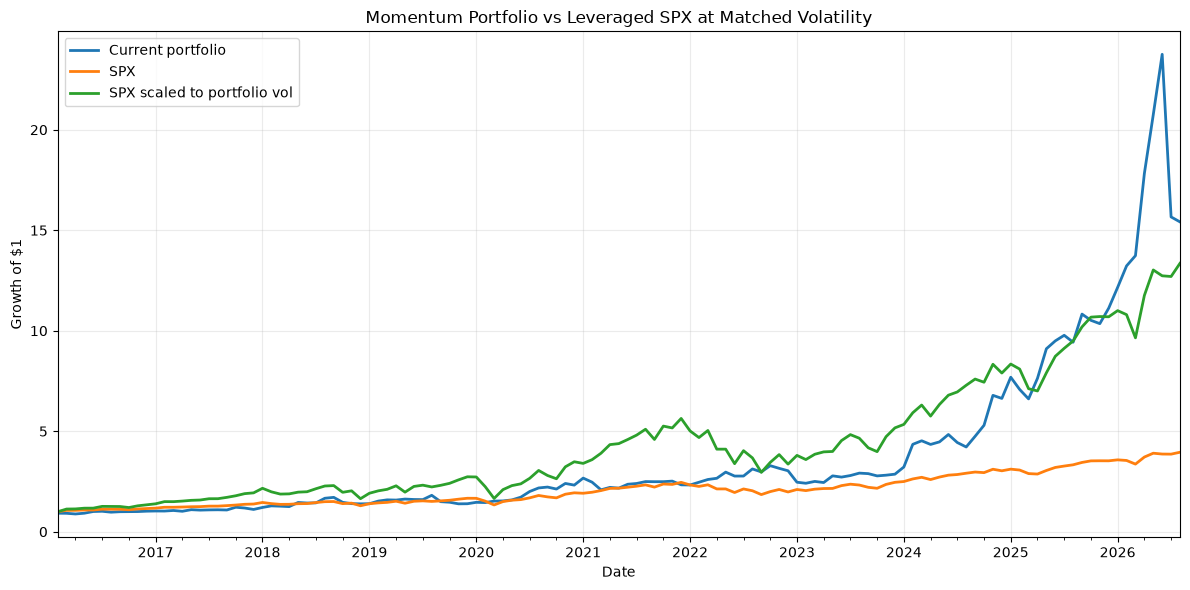

Comparison period: 2016-02 to 2026-08 (127 months)
SPX -> portfolio volatility: 2.10x leverage (15.04% to 31.53%)


,Total return,Annualized return,Annualized volatility,Sharpe (rf=0),Max drawdown,Correlation vs SPX,Beta vs SPX
Current portfolio,1441.51%,29.49%,31.53%,0.98,-35.10%,0.22,0.46
SPX,295.54%,13.87%,15.04%,0.94,-24.77%,nan,nan
SPX scaled to portfolio vol,1235.55%,27.75%,31.53%,0.94,-47.58%,1.00,2.10


In [6]:
# 6) Compare the current momentum portfolio with the S&P 500 (SPX).
import matplotlib.pyplot as plt

spx_prices = yf.download(
    "^GSPC",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
    threads=False,
)["Close"]
if isinstance(spx_prices, pd.DataFrame):
    spx_prices = spx_prices.squeeze("columns")

spx_returns = (
    spx_prices.resample(REBALANCE_FREQUENCY).last().pct_change().rename("SPX")
)
comparison_returns = pd.concat(
    [momentum_backtest_returns.rename("Current portfolio"), spx_returns], axis=1
).dropna()

# Scale SPX up to the current portfolio's realized volatility.
portfolio_volatility = comparison_returns["Current portfolio"].std() * np.sqrt(12)
spx_volatility = comparison_returns["SPX"].std() * np.sqrt(12)
spx_to_portfolio_factor = portfolio_volatility / spx_volatility
comparison_returns["SPX scaled to portfolio vol"] = (
    comparison_returns["SPX"] * spx_to_portfolio_factor
)


def performance_metrics(return_series):
    equity_curve = (1 + return_series).cumprod()
    periods = len(return_series)
    total_return = equity_curve.iloc[-1] - 1
    annualized_return = (1 + total_return) ** (12 / periods) - 1
    annualized_volatility = return_series.std() * np.sqrt(12)
    sharpe = return_series.mean() / return_series.std() * np.sqrt(12)
    max_drawdown = (equity_curve / equity_curve.cummax() - 1).min()
    return pd.Series({
        "Total return": total_return,
        "Annualized return": annualized_return,
        "Annualized volatility": annualized_volatility,
        "Sharpe (rf=0)": sharpe,
        "Max drawdown": max_drawdown,
    })

comparison_summary = comparison_returns.apply(performance_metrics).T
comparison_summary["Correlation vs SPX"] = np.nan
comparison_summary["Beta vs SPX"] = np.nan
for portfolio_name in ["Current portfolio", "SPX scaled to portfolio vol"]:
    comparison_summary.loc[portfolio_name, "Correlation vs SPX"] = (
        comparison_returns[portfolio_name].corr(comparison_returns["SPX"])
    )
    comparison_summary.loc[portfolio_name, "Beta vs SPX"] = (
        comparison_returns[portfolio_name].cov(comparison_returns["SPX"])
        / comparison_returns["SPX"].var()
    )

comparison_equity = (1 + comparison_returns).cumprod()
comparison_equity[[
    "Current portfolio",
    "SPX",
    "SPX scaled to portfolio vol",
]].plot(
    figsize=(12, 6),
    linewidth=2,
    title="Momentum Portfolio vs Leveraged SPX at Matched Volatility",
)
ax = plt.gca()
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(
    f"Comparison period: {comparison_returns.index.min():%Y-%m} to "
    f"{comparison_returns.index.max():%Y-%m} ({len(comparison_returns)} months)"
)
print(
    f"SPX -> portfolio volatility: {spx_to_portfolio_factor:.2f}x leverage "
    f"({spx_volatility:.2%} to {portfolio_volatility:.2%})"
)
comparison_summary.style.format("{:.2%}", subset=[
    "Total return", "Annualized return", "Annualized volatility", "Max drawdown"
]).format("{:.2f}", subset=["Sharpe (rf=0)", "Correlation vs SPX", "Beta vs SPX"])


In [ ]:
# 7) Risk analyst daily position and exposure handoff.
PORTFOLIO_NAV = 1_000_000

# Convert monthly portfolio weights into daily holdings by carrying each rebalance forward.
daily_weights = (
    momentum_weight_history.reindex(prices.index, method="ffill")
    .reindex(columns=prices.columns)
    .fillna(0.0)
)
daily_prices = prices.reindex(daily_weights.index).reindex(columns=daily_weights.columns)
daily_shares = PORTFOLIO_NAV * daily_weights.div(daily_prices)
daily_market_values = daily_shares * daily_prices

daily_pnl = daily_shares.shift(1) * daily_prices.diff()
daily_pnl = daily_pnl.fillna(0.0)

latest_date = daily_weights.index[-1]
latest_positions = pd.DataFrame({
    "date": latest_date,
    "ticker": daily_weights.columns,
    "side": np.where(daily_weights.loc[latest_date] >= 0, "Long", "Short"),
    "weight": daily_weights.loc[latest_date].values,
    "price": daily_prices.loc[latest_date].values,
    "shares": daily_shares.loc[latest_date].values,
    "market_value": daily_market_values.loc[latest_date].values,
    "prior_day_pnl": daily_pnl.loc[latest_date].values,
})
latest_positions = latest_positions.loc[
    latest_positions["weight"] != 0
].sort_values("weight", ascending=False)

print(f"Risk handoff date: {latest_date:%Y-%m-%d}")
print(f"Portfolio NAV: ${PORTFOLIO_NAV:,.0f}")
print(
    f"Gross exposure: ${latest_positions['market_value'].abs().sum():,.0f}; "
    f"net exposure: ${latest_positions['market_value'].sum():,.0f}"
)
latest_positions.style.format({
    "weight": "{:.2%}",
    "price": "${:,.2f}",
    "shares": "{:,.2f}",
    "market_value": "${:,.2f}",
    "prior_day_pnl": "${:,.2f}",
})

print("Daily market-value exposure matrix (last five trading days):")
daily_market_values.tail()

print("Daily P&L matrix (last five trading days):")
daily_pnl.tail()


Risk handoff date: 2026-08-21
Portfolio NAV: $1,000,000
Gross exposure: $2,000,000; net exposure: $-0
Daily market-value exposure matrix (last five trading days):
Daily P&L matrix (last five trading days):


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,...,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-17,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,1453.346411,1871.827172,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,68.785736
2026-08-18,-0.0,0.0,0.0,0.0,0.0,0.0,-645.680838,-1773.832141,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,...,0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,-83.979274
2026-08-19,0.0,0.0,0.0,0.0,0.0,-0.0,-2203.048264,-1755.764747,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-227.643060
2026-08-20,0.0,-0.0,-0.0,-0.0,-0.0,0.0,369.665822,45.435312,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,...,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,134.001344
2026-08-21,0.0,-0.0,0.0,0.0,0.0,0.0,-806.247371,-560.274675,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,...,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-223.601926


In [ ]:
# 8) Historical positions, weights, prices, returns, and P&L in one table.
daily_security_returns = daily_prices.pct_change()

historical_positions_table = pd.concat(
    {
        "weight": daily_weights.stack(dropna=False),
        "price": daily_prices.stack(dropna=False),
        "shares": daily_shares.stack(dropna=False),
        "market_value": daily_market_values.stack(dropna=False),
        "security_return": daily_security_returns.stack(dropna=False),
        "pnl": daily_pnl.stack(dropna=False),
    },
    axis=1,
).reset_index(names=["date", "ticker"])

historical_positions_table = historical_positions_table.loc[
    historical_positions_table["weight"] != 0
].sort_values(["date", "ticker"])
historical_positions_table["side"] = np.where(
    historical_positions_table["weight"] > 0, "Long", "Short"
)
historical_positions_table = historical_positions_table[
    [
        "date",
        "ticker",
        "side",
        "weight",
        "price",
        "shares",
        "market_value",
        "security_return",
        "pnl",
    ]
]

print(
    f"Historical position rows: {len(historical_positions_table):,}; "
    f"dates: {historical_positions_table['date'].nunique()}; "
    f"securities: {historical_positions_table['ticker'].nunique()}"
)
historical_positions_table.tail(20).style.format({
    "weight": "{:.2%}",
    "price": "${:,.2f}",
    "shares": "{:,.2f}",
    "market_value": "${:,.2f}",
    "security_return": "{:.2%}",
    "pnl": "${:,.2f}",
})

Historical position rows: 158,160; dates: 2636; securities: 444
Saved historical_positions.csv


,date,ticker,side,weight,price,shares,market_value,security_return,pnl
1459885,2026-08-21 00:00:00,MPWR,Long,0.03%,"$1,316.28",0.23,$297.64,0.43%,$1.29
1459889,2026-08-21 00:00:00,MRVL,Long,2.71%,$237.04,114.42,"$27,122.00",-5.57%,"$-1,509.48"
1459896,2026-08-21 00:00:00,MU,Long,11.34%,$966.78,117.32,"$113,422.22",-0.77%,$-878.90
1459911,2026-08-21 00:00:00,NUE,Long,0.01%,$243.63,0.52,$125.56,1.31%,$1.64
1459921,2026-08-21 00:00:00,ON,Long,0.80%,$74.21,108.29,"$8,036.15",-0.67%,$-53.78
1459927,2026-08-21 00:00:00,PAYX,Short,-5.66%,$124.48,-454.56,"$-56,583.22",1.28%,$-722.77
1459945,2026-08-21 00:00:00,PODD,Short,-0.10%,$148.16,-6.78,"$-1,004.52",0.88%,$-8.82
1459954,2026-08-21 00:00:00,PYPL,Short,-10.21%,$61.55,"-1,658.63","$-102,088.84",-1.20%,"$1,229.00"
1459966,2026-08-21 00:00:00,ROP,Short,-2.28%,$411.79,-55.48,"$-22,848.14",0.33%,$-74.59
1459988,2026-08-21 00:00:00,STX,Long,8.17%,$850.00,96.16,"$81,738.04",-0.03%,$-23.07


# Risk Model Inputs and Conventions

The model uses adjusted daily prices for the current S&P 500 constituents. The strategy return is built from dated long and short weights, and the portfolio risk analysis uses the same return convention and dates wherever possible.

The public factor proxies are:

| Factor | Proxy construction | Interpretation |
|---|---|---|
| Market | SPY | Broad equity-market exposure |
| Size | IWM minus SPY | Smaller-company exposure relative to large companies |
| Value | IWD minus IWF | Value exposure relative to growth |
| Momentum | MTUM minus SPY | Momentum exposure relative to the market |
| Quality | QUAL minus SPY | Quality exposure relative to the market |
| Low volatility | USMV minus SPY | Minimum-volatility exposure relative to the market |

These are practical public proxies, not exact Barra factors. They are suitable for a transparent research workflow, but a production model should use dated vendor security exposures, factor returns, factor covariance, and specific-risk estimates.

# Barra-Style Risk Analysis Report

## What This Section Does

This section treats the portfolio as a risk object rather than only a return series. It estimates systematic factor exposure, separates common-factor and residual risk, tests whether risk changes over time, and converts the findings into reviewable stress and de-risking actions.

## Core Model

The portfolio return is modeled as:

$$
r_{p,t} = \alpha + B_p f_t + \epsilon_t
$$

where $B_p$ is the portfolio factor-beta vector, $f_t$ is the vector of daily factor returns, and $\epsilon_t$ is residual security-specific return.

Common-factor variance is estimated as:

$$
\sigma^2_{common} = B_p \Sigma_f B_p^T
$$

Total modeled variance adds residual variance. This identifies whether observed portfolio risk is primarily systematic or security-specific.

## Risk Questions Answered

- **Is the portfolio outside a factor limit?** Review the factor exposure and risk-limit outputs.
- **Is the style identity drifting?** Review rolling factor betas over time.
- **Which factors dominate risk?** Review factor variance contribution and concentration.
- **Could several risks unwind together?** Review factor-correlation shifts and stress scenarios.
- **Which names deserve attention?** Review specific-risk concentration, MCTR, and the security-level beta maps.
- **Is the model reliable?** Compare ex-ante forecast volatility with subsequent realized volatility.

## How to Use the Results

A factor breach calls for factor-aware action. A broad market sell-off calls for an exposure overlay. A concentrated position-level problem calls for MCTR and constrained reallocation. These actions should be evaluated together with turnover, liquidity, borrow, financing, mandate, and transaction-cost constraints.

In [ ]:
# 9) Public-proxy Barra-style factor exposure and risk report.
from IPython.display import display

proxy_tickers = ["SPY", "IWM", "IWD", "IWF", "MTUM", "QUAL", "USMV"]
proxy_prices = yf.download(
    proxy_tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True,
)["Close"]
if isinstance(proxy_prices, pd.Series):
    proxy_prices = proxy_prices.to_frame()

proxy_returns = proxy_prices.pct_change().rename(columns={
    "SPY": "Market",
    "IWM": "Size proxy",
    "IWD": "Value proxy",
    "IWF": "Growth proxy",
    "MTUM": "Momentum proxy",
    "QUAL": "Quality proxy",
    "USMV": "Low-vol proxy",
})
factor_returns = pd.DataFrame({
    "Market": proxy_returns["Market"],
    "Size": proxy_returns["Size proxy"] - proxy_returns["Market"],
    "Value": proxy_returns["Value proxy"] - proxy_returns["Growth proxy"],
    "Momentum": proxy_returns["Momentum proxy"] - proxy_returns["Market"],
    "Quality": proxy_returns["Quality proxy"] - proxy_returns["Market"],
    "Low volatility": proxy_returns["Low-vol proxy"] - proxy_returns["Market"],
})

portfolio_daily_returns = (daily_pnl.sum(axis=1) / PORTFOLIO_NAV).rename("Portfolio")
model_data = pd.concat([portfolio_daily_returns, factor_returns], axis=1).dropna()

factor_names = factor_returns.columns.tolist()
design_matrix = np.column_stack([
    np.ones(len(model_data)),
    model_data[factor_names].to_numpy(),
])
coefficients = np.linalg.lstsq(
    design_matrix, model_data["Portfolio"].to_numpy(), rcond=None
)[0]
alpha = coefficients[0]
betas = pd.Series(coefficients[1:], index=factor_names, name="beta")
fitted_returns = design_matrix @ coefficients
residual_returns = model_data["Portfolio"] - fitted_returns

factor_attribution = pd.DataFrame({
    "beta": betas,
    "annualized_factor_return": model_data[factor_names].mean() * 252,
})
factor_attribution["annualized_contribution"] = (
    factor_attribution["beta"] * factor_attribution["annualized_factor_return"]
)
factor_covariance = model_data[factor_names].cov() * 252
factor_variance = float(betas @ factor_covariance @ betas)
specific_variance = float(residual_returns.var() * 252)
model_volatility = np.sqrt(factor_variance + specific_variance)
realized_volatility = model_data["Portfolio"].std() * np.sqrt(252)
risk_summary = pd.Series({
    "Annualized alpha": alpha * 252,
    "Annualized portfolio return": model_data["Portfolio"].mean() * 252,
    "Annualized factor return contribution": factor_attribution["annualized_contribution"].sum(),
    "Realized volatility": realized_volatility,
    "Factor volatility": np.sqrt(factor_variance),
    "Specific volatility": np.sqrt(specific_variance),
    "Model volatility": model_volatility,
    "Common-factor risk share": factor_variance / (factor_variance + specific_variance),
    "Regression R-squared": 1 - residual_returns.var() / model_data["Portfolio"].var(),
})

print("Public-proxy Barra-style factor exposure report:")
display(factor_attribution.style.format({
    "beta": "{:.3f}",
    "annualized_factor_return": "{:.2%}",
    "annualized_contribution": "{:.2%}",
}))

print("Risk decomposition:")
display(risk_summary.to_frame("value").style.format("{:.2%}"))

Public-proxy Barra-style factor exposure report:


,beta,annualized_factor_return,annualized_contribution
Market,0.179,14.54%,2.60%
Size,0.027,-2.78%,-0.07%
Value,-0.168,-5.69%,0.96%
Momentum,2.257,1.77%,3.99%
Quality,-0.664,-0.50%,0.33%
Low volatility,-0.746,-3.81%,2.84%


Risk decomposition:


,value
Annualized alpha,13.97%
Annualized portfolio return,24.62%
Annualized factor return contribution,10.64%
Realized volatility,33.93%
Factor volatility,26.77%
Specific volatility,20.84%
Model volatility,33.93%
Common-factor risk share,62.26%
Regression R-squared,62.26%


Saved barra_proxy_factor_attribution.csv
Saved barra_proxy_risk_summary.csv
Saved barra_proxy_factor_returns.csv


## 1. Style Drift Over Time

The table compares the latest rolling factor beta with the beta one year earlier. The chart shows whether the portfolio's style identity is changing. Large changes should be reviewed against the investment thesis, rebalance history, and changes in the investable universe.

Style drift report:


,latest_beta,one_year_ago_beta,change
Market,-0.276,0.025,-0.301
Size,0.032,0.448,-0.416
Value,-0.438,-1.399,+0.962
Momentum,2.456,2.983,-0.527
Quality,-1.262,-0.730,-0.533
Low volatility,-0.853,0.156,-1.009


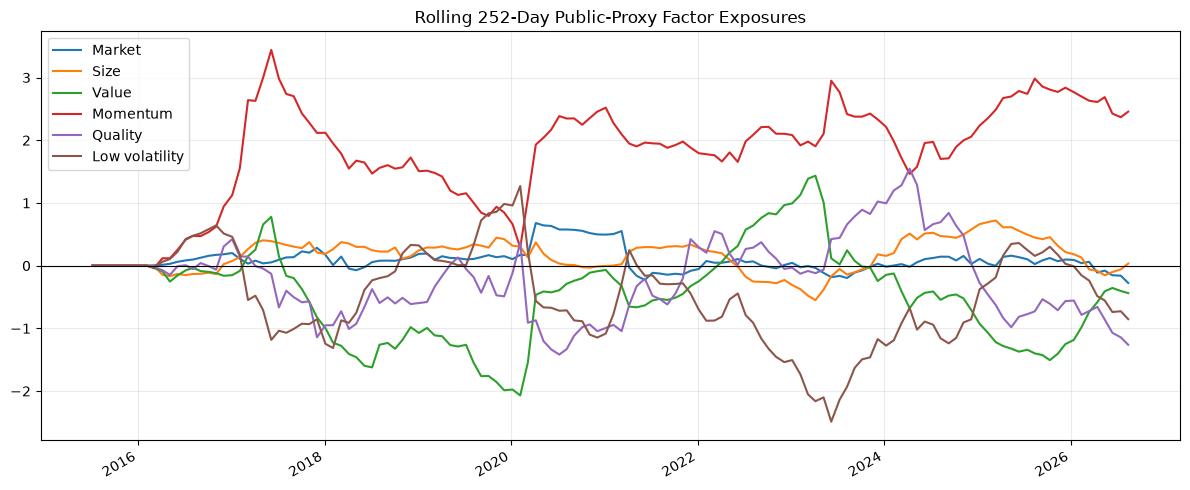

In [ ]:
# Question 1: Style drift over time.
from IPython.display import display

ROLLING_WINDOW = 252
MIN_ROLLING_OBSERVATIONS = 126
rolling_beta_rows = []
for end_index in range(MIN_ROLLING_OBSERVATIONS, len(model_data) + 1, 21):
    window = model_data.iloc[max(0, end_index - ROLLING_WINDOW):end_index]
    rolling_design = np.column_stack([
        np.ones(len(window)),
        window[factor_names].to_numpy(),
    ])
    rolling_coefficients = np.linalg.lstsq(
        rolling_design, window["Portfolio"].to_numpy(), rcond=None
    )[0]
    rolling_beta_rows.append(
        pd.Series(rolling_coefficients[1:], index=factor_names, name=window.index[-1])
    )
rolling_betas = pd.DataFrame(rolling_beta_rows)
style_drift = pd.DataFrame({
    "latest_beta": rolling_betas.iloc[-1],
    "one_year_ago_beta": rolling_betas.iloc[-13].reindex(factor_names),
})
style_drift["change"] = style_drift["latest_beta"] - style_drift["one_year_ago_beta"]

print("Style drift report:")
display(style_drift.style.format({
    "latest_beta": "{:.3f}",
    "one_year_ago_beta": "{:.3f}",
    "change": "{:+.3f}",
}))
rolling_betas.plot(figsize=(12, 5), title="Rolling 252-Day Public-Proxy Factor Exposures")
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 2. Unintended Factor Bets

A portfolio can have near-zero market beta while carrying large style betas. This report flags absolute rolling beta of at least 0.50. A flag is a review trigger, not an automatic breach: compare it with the strategy mandate before deciding whether to hedge or resize the exposure.


In [ ]:
# Question 2: Unintended factor bets.
hidden_bets = style_drift.loc[style_drift["latest_beta"].abs() >= 0.50].copy()
print("Current hidden-bet flags:")
display(hidden_bets.style.format({
    "latest_beta": "{:+.3f}",
    "one_year_ago_beta": "{:+.3f}",
    "change": "{:+.3f}",
}))

Current hidden-bet flags:


,latest_beta,one_year_ago_beta,change
Momentum,+2.456,+2.983,-0.527
Quality,-1.262,-0.730,-0.533
Low volatility,-0.853,+0.156,-1.009


## 3. Factor Concentration

This table allocates common-factor variance using the factor covariance matrix. A high absolute share means the portfolio is diversified across securities but concentrated in a small number of systematic sources. Momentum should be treated as a concentration limit, not only as a return signal.


In [ ]:
# Question 3: Factor concentration.
factor_covariance_daily = factor_series.cov()
variance_contributions = betas * factor_covariance_daily.dot(betas)
variance_concentration = pd.DataFrame({
    "variance_contribution": variance_contributions * 252,
    "absolute_share_of_factor_risk": (
        variance_contributions.abs() / variance_contributions.abs().sum()
    ),
}).sort_values("absolute_share_of_factor_risk", ascending=False)

print("Factor risk concentration:")
display(variance_concentration.style.format({
    "variance_contribution": "{:.2%}",
    "absolute_share_of_factor_risk": "{:.2%}",
}))

Factor risk concentration:


,variance_contribution,absolute_share_of_factor_risk
Momentum,5.61%,78.31%
Low volatility,0.80%,11.20%
Value,0.31%,4.30%
Market,0.30%,4.23%
Quality,0.14%,1.94%
Size,0.00%,0.03%


## 4. Crowding Risk

A true crowding analysis requires peer portfolios or a common-holder dataset. This public-proxy version flags unusually stretched factor exposures using rolling z-scores. A flagged factor is a monitoring signal, not proof that other funds hold the same names.


In [ ]:
# Question 4: Crowding risk proxy.
rolling_factor_zscores = (
    (rolling_betas - rolling_betas.rolling(12, min_periods=6).mean())
    / rolling_betas.rolling(12, min_periods=6).std()
)
crowding_proxy = pd.DataFrame({
    "latest_exposure": rolling_betas.iloc[-1],
    "latest_12m_zscore": rolling_factor_zscores.iloc[-1],
    "stretched_exposure_flag": rolling_factor_zscores.iloc[-1].abs() >= 2,
})

print("Crowding proxy; peer holdings are required for true peer crowding:")
display(crowding_proxy.style.format({
    "latest_exposure": "{:.3f}",
    "latest_12m_zscore": "{:.2f}",
}))

Crowding proxy; peer holdings are required for true peer crowding:


,latest_exposure,latest_12m_zscore,stretched_exposure_flag
Market,-0.276,-1.96,False
Size,0.032,-0.36,False
Value,-0.438,1.00,False
Momentum,2.456,-1.22,False
Quality,-1.262,-1.92,False
Low volatility,-0.853,-1.47,False


## 5. Factor Covariance Shifts

The factor covariance matrix is not static. This comparison shows which factor pairs have changed correlation most between the current and prior one-year windows. Rising positive correlation reduces diversification exactly when multiple factor bets may unwind together.


In [ ]:
# Question 5: Factor covariance shifts.
current_factor_corr = factor_series.tail(ROLLING_WINDOW).corr()
prior_factor_corr = factor_series.iloc[-2 * ROLLING_WINDOW:-ROLLING_WINDOW].corr()
correlation_shift = current_factor_corr - prior_factor_corr
upper_triangle = np.triu(np.ones(current_factor_corr.shape, dtype=bool), k=1)
correlation_shift_table = (
    correlation_shift.where(upper_triangle).stack().rename("correlation_change")
)

print("Largest factor-correlation shifts over the last year:")
display(correlation_shift_table.abs().sort_values(ascending=False).head(10).to_frame())

Largest factor-correlation shifts over the last year:


correlation_change
Momentum Low volatility            0.414468
Market   Quality                   0.220647
Size     Momentum                  0.218878
Market   Size                      0.191166
         Momentum                  0.182286
Quality  Low volatility            0.153618
Value    Low volatility            0.152913
Momentum Quality                   0.113476
Size     Low volatility            0.104547
         Quality                   0.096956

## 6. Specific-Risk Concentration

This table uses position-level daily P&L covariance as a public-data proxy for specific-risk contribution. It highlights names whose P&L moves explain a large share of portfolio variance. A production Barra model should replace this proxy with vendor-specific risk and the full factor covariance matrix.


In [ ]:
# Question 6: Specific-risk concentration proxy.
total_daily_pnl = daily_pnl.sum(axis=1)
single_name_covariance = daily_pnl.apply(lambda column: column.cov(total_daily_pnl))
specific_risk_concentration = pd.DataFrame({
    "variance_contribution": single_name_covariance * 252,
    "absolute_share_of_portfolio_variance": (
        single_name_covariance.abs() / single_name_covariance.abs().sum()
    ),
}).sort_values("absolute_share_of_portfolio_variance", ascending=False)

print("Top single-name risk contributors (P&L covariance proxy):")
display(specific_risk_concentration.head(15).style.format({
    "variance_contribution": "${:,.0f}",
    "absolute_share_of_portfolio_variance": "{:.2%}",
}))

Top single-name risk contributors (P&L covariance proxy):


,variance_contribution,absolute_share_of_portfolio_variance
Ticker,,
CVNA,"$8,027,847,177",6.79%
LITE,"$3,974,472,457",3.36%
APP,"$3,845,647,012",3.25%
PLTR,"$3,563,028,253",3.01%
AMD,"$3,509,599,006",2.97%
TTD,"$3,374,588,853",2.85%
SMCI,"$3,280,291,289",2.77%
WDC,"$3,126,668,222",2.64%
NVDA,"$3,109,275,565",2.63%


## 7. Ex-Ante Versus Realized Risk

The final row compares forecast volatility from the rolling factor model with subsequent 21-day realized volatility. A realized-to-forecast ratio persistently above 1.0 means the model is underestimating risk and should be recalibrated before its numbers are used in an investment-committee report.


## Risk Diagnostics to De-Risking Decisions

The risk report is designed to move from diagnosis to action:

1. Identify the breached factor, concentration, or stress limit.
2. Determine whether the risk is broad across the book or concentrated in a few names.
3. Use a universal exposure trim for fast systemic risk reduction.
4. Use MCTR and position-level factor data to target individual contributors.
5. Use constrained optimization to choose the sell-and-buy combination while preserving factor, return, turnover, liquidity, and mandate requirements.
6. Recalculate exposures and stress loss after the proposed action.

A de-risking action is successful only when it reduces the intended risk without creating a larger unintended exposure elsewhere.

In [ ]:
# Question 7: Ex-ante versus realized risk validation.
forecast_rows = []
for end_index in range(ROLLING_WINDOW, len(model_data)):
    window = model_data.iloc[end_index - ROLLING_WINDOW:end_index]
    window_design = np.column_stack([
        np.ones(len(window)),
        window[factor_names].to_numpy(),
    ])
    window_coefficients = np.linalg.lstsq(
        window_design, window["Portfolio"].to_numpy(), rcond=None
    )[0]
    window_betas = window_coefficients[1:]
    window_residuals = window["Portfolio"].to_numpy() - window_design @ window_coefficients
    forecast_variance = (
        window_betas @ (window[factor_names].cov().to_numpy() * 252) @ window_betas
        + window_residuals.var() * 252
    )
    forecast_rows.append((window.index[-1], np.sqrt(forecast_variance)))
ex_ante_volatility = pd.Series(dict(forecast_rows), name="ex_ante_volatility")
realized_volatility_21d = portfolio_series.rolling(21).std() * np.sqrt(252)
validation = pd.concat([
    ex_ante_volatility,
    realized_volatility_21d.rename("realized_21d_volatility"),
], axis=1).dropna()
validation["realized_to_forecast_ratio"] = (
    validation["realized_21d_volatility"] / validation["ex_ante_volatility"]
)

print("Ex-ante versus realized volatility validation:")
display(validation.tail(1).style.format("{:.2%}"))

Ex-ante versus realized volatility validation:


,ex_ante_volatility,realized_21d_volatility,realized_to_forecast_ratio
2026-08-20 00:00:00,59.02%,102.34%,173.40%


# Security-Level Factor Beta Map: Portfolio Position Review

This section moves from portfolio-level factor exposure to the individual names that create it. For the top 10 current longs and top 10 current shorts, each security is regressed on the same six public factor proxies over the latest three years of available daily data.

The graph uses annualized security return on the y-axis, security factor beta on the x-axis, bubble size for absolute current weight, and color/marker shape for long versus short direction. The original beta table remains the source for exact values; the graph is for prioritizing position review.

The main questions are:

- Which large positions have the strongest factor tilts?
- Are large shorts exposed to stocks with strong positive realized returns?
- Are several holdings clustered around the same factor direction?
- Which names should be protected, trimmed, hedged, or passed to the constrained optimizer?

In [16]:
# Prepare daily weights and plotting dependencies for the security-level beta map.
import matplotlib.pyplot as plt

if "daily_weights" not in globals():
    daily_weights = (
        momentum_weight_history.reindex(prices.index, method="ffill")
        .reindex(columns=prices.columns)
        .fillna(0.0)
    )

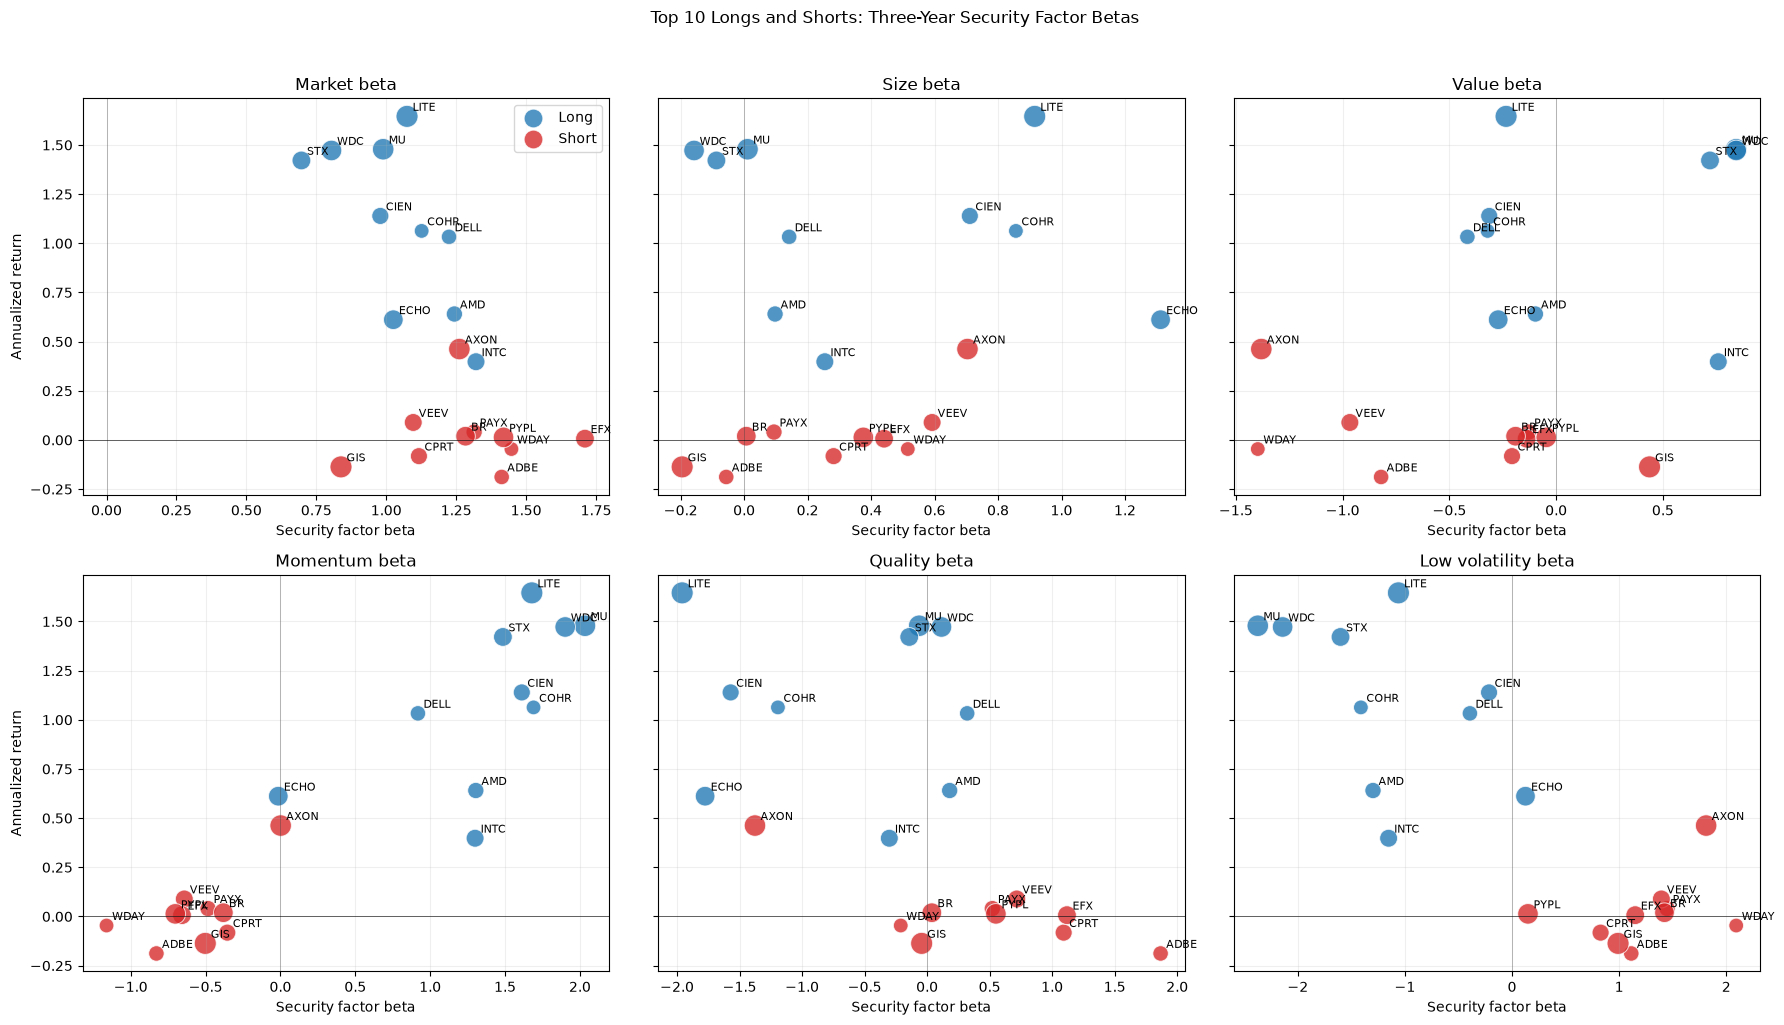

Security-level beta and return matrix:


,Side,Current weight,Annualized return,Market,Size,Value,Momentum,Quality,Low volatility
Ticker,,,,,,,,,
LITE,Long,+12.00%,+164.55%,+1.074,+0.916,-0.235,+1.679,-1.959,-1.060
MU,Long,+11.34%,+147.83%,+0.989,+0.011,+0.843,+2.034,-0.063,-2.373
WDC,Long,+10.21%,+147.21%,+0.804,-0.158,+0.843,+1.902,+0.115,-2.142
ECHO,Long,+9.15%,+61.16%,+1.025,+1.312,-0.271,-0.014,-1.775,+0.126
STX,Long,+8.17%,+142.13%,+0.697,-0.087,+0.721,+1.486,-0.143,-1.601
INTC,Long,+7.27%,+39.78%,+1.321,+0.254,+0.759,+1.300,-0.302,-1.152
CIEN,Long,+6.43%,+113.92%,+0.979,+0.711,-0.313,+1.612,-1.571,-0.215
AMD,Long,+5.66%,+64.05%,+1.243,+0.097,-0.097,+1.305,+0.180,-1.298
DELL,Long,+4.95%,+103.28%,+1.224,+0.142,-0.416,+0.918,+0.320,-0.393


Window: 2023-08-17 to 2026-08-21; 10 longs and 10 shorts


In [17]:
# Three-year security-level factor betas for the top 10 longs and shorts.
from IPython.display import display

factor_beta_window = 756
if "factor_returns" not in globals():
    beta_proxy_tickers = ["SPY", "IWM", "IWD", "IWF", "MTUM", "QUAL", "USMV"]
    beta_proxy_prices = yf.download(
        beta_proxy_tickers,
        start=prices.index.min().strftime("%Y-%m-%d"),
        end=(prices.index.max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True,
    )["Close"]
    if isinstance(beta_proxy_prices, pd.Series):
        beta_proxy_prices = beta_proxy_prices.to_frame()
    beta_proxy_returns = beta_proxy_prices.pct_change()
    factor_returns = pd.DataFrame({
        "Market": beta_proxy_returns["SPY"],
        "Size": beta_proxy_returns["IWM"] - beta_proxy_returns["SPY"],
        "Value": beta_proxy_returns["IWD"] - beta_proxy_returns["IWF"],
        "Momentum": beta_proxy_returns["MTUM"] - beta_proxy_returns["SPY"],
        "Quality": beta_proxy_returns["QUAL"] - beta_proxy_returns["SPY"],
        "Low volatility": beta_proxy_returns["USMV"] - beta_proxy_returns["SPY"],
    })
factor_names = factor_returns.columns.tolist()
security_returns = prices.pct_change()

latest_position_weights = daily_weights.iloc[-1].reindex(prices.columns).dropna()
latest_position_weights = latest_position_weights[latest_position_weights != 0]
top_long_names = latest_position_weights[latest_position_weights > 0].nlargest(10).index.tolist()
top_short_names = latest_position_weights[latest_position_weights < 0].nsmallest(10).index.tolist()
selected_names = top_long_names + top_short_names

security_model_data = pd.concat(
    [security_returns[selected_names], factor_returns], axis=1
).dropna().tail(factor_beta_window)
security_beta_rows = []
for name in selected_names:
    security_data = security_model_data[[name] + factor_names].dropna()
    design_matrix = np.column_stack([
        np.ones(len(security_data)),
        security_data[factor_names].to_numpy(),
    ])
    coefficients = np.linalg.lstsq(
        design_matrix, security_data[name].to_numpy(), rcond=None
    )[0]
    security_return = security_data[name]
    security_beta_rows.append({
        "Ticker": name,
        "Side": "Long" if latest_position_weights[name] > 0 else "Short",
        "Current weight": latest_position_weights[name],
        "Annualized return": (1 + security_return).prod() ** (252 / len(security_return)) - 1,
        **dict(zip(factor_names, coefficients[1:])),
    })

security_factor_beta_table = pd.DataFrame(security_beta_rows).set_index("Ticker")
security_factor_beta_table = security_factor_beta_table.sort_values(
    ["Side", "Current weight"], ascending=[True, False]
)

figure, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
for axis, factor_name in zip(axes.flat, factor_names):
    for side, color in [("Long", "tab:blue"), ("Short", "tab:red")]:
        subset = security_factor_beta_table[security_factor_beta_table["Side"] == side]
        axis.scatter(
            subset[factor_name],
            subset["Annualized return"],
            s=subset["Current weight"].abs() * 1800 + 35,
            alpha=0.78,
            color=color,
            label=side if factor_name == factor_names[0] else None,
            edgecolor="white",
            linewidth=0.7,
        )
        for ticker, row in subset.iterrows():
            axis.annotate(
                ticker,
                (row[factor_name], row["Annualized return"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )
    axis.axhline(0, color="black", linewidth=0.7, alpha=0.6)
    axis.axvline(0, color="black", linewidth=0.7, alpha=0.25)
    axis.set_title(f"{factor_name} beta")
    axis.set_xlabel("Security factor beta")
    axis.grid(alpha=0.2)
axes[0, 0].set_ylabel("Annualized return")
axes[1, 0].set_ylabel("Annualized return")
axes[0, 0].legend()
figure.suptitle("Top 10 Longs and Shorts: Three-Year Security Factor Betas", y=1.02)
plt.tight_layout()
plt.show()

print("Security-level beta and return matrix:")
display(security_factor_beta_table.style.format({
    "Current weight": "{:+.2%}",
    "Annualized return": "{:+.2%}",
    **{factor_name: "{:+.3f}" for factor_name in factor_names},
}))
print(
    f"Window: {security_model_data.index.min():%Y-%m-%d} to "
    f"{security_model_data.index.max():%Y-%m-%d}; "
    f"{len(top_long_names)} longs and {len(top_short_names)} shorts"
)

## Interpretation of the Security Map

The largest bubbles far from the origin deserve the first review because they combine meaningful capital with strong factor exposure. A large long with a positive beta to an already concentrated factor may be a source of both return and drawdown risk. A large short with positive realized return may be an adverse short-selection decision.

Use the original beta table for exact factor values and the multidimensional map for clustering. The PCA map reduces the six beta dimensions into a visual two-dimensional space; its axes are combinations of factors, not new economic factors. Points in the same direction indicate similar combined factor behavior, while points far from the origin have stronger combined tilts.

These are historical regression relationships over approximately 2023-08-17 to 2026-08-21. They measure co-movement, not causality or a forecast. Final trading decisions should combine the map with MCTR, factor limits, expected return, liquidity, borrow, and portfolio-mandate constraints.

# Final Investment Risk Handoff

The recommended review sequence is:

1. Confirm the latest positions, weights, gross exposure, and net exposure.
2. Review factor exposure and identify any factor-limit breach.
3. Review factor concentration, drawdown stress, and realized-versus-forecast volatility.
4. Use the security beta map and MCTR to identify the highest-priority names.
5. Select the response: universal trim for broad stress, individual trim for concentrated risk, factor hedge for a systematic exposure, or constrained optimization when required holdings must be protected.
6. Recalculate portfolio risk after the proposed action and test the decision out of sample.

This notebook is a public-data research proxy. A production Barra handoff would replace ETF proxies with dated vendor security exposures and risk estimates, add transaction costs, liquidity, borrow, financing, and mandate constraints, and maintain a walk-forward audit trail for every rebalance decision.

## Multidimensional Factor Tilt Map

The six individual scatter plots above are useful for one-factor questions, but they do not show the combined factor identity of each security. This map uses **principal component analysis (PCA)** on the six security beta estimates to create a two-dimensional factor space.

- Each bubble is one of the top 10 long or top 10 short positions.
- Bubble size is proportional to absolute current portfolio weight.
- Blue points are longs and red points are shorts.
- Point color identifies the factor with the largest absolute beta for that security.
- Arrows show the direction of each original factor in the PCA space.

The map is a visual classification tool. PCA axes are combinations of the original factors, so the arrows and the original beta table should be read together. A point close to a factor arrow is more tilted toward that factor; a point far from the origin has a stronger combined factor profile.

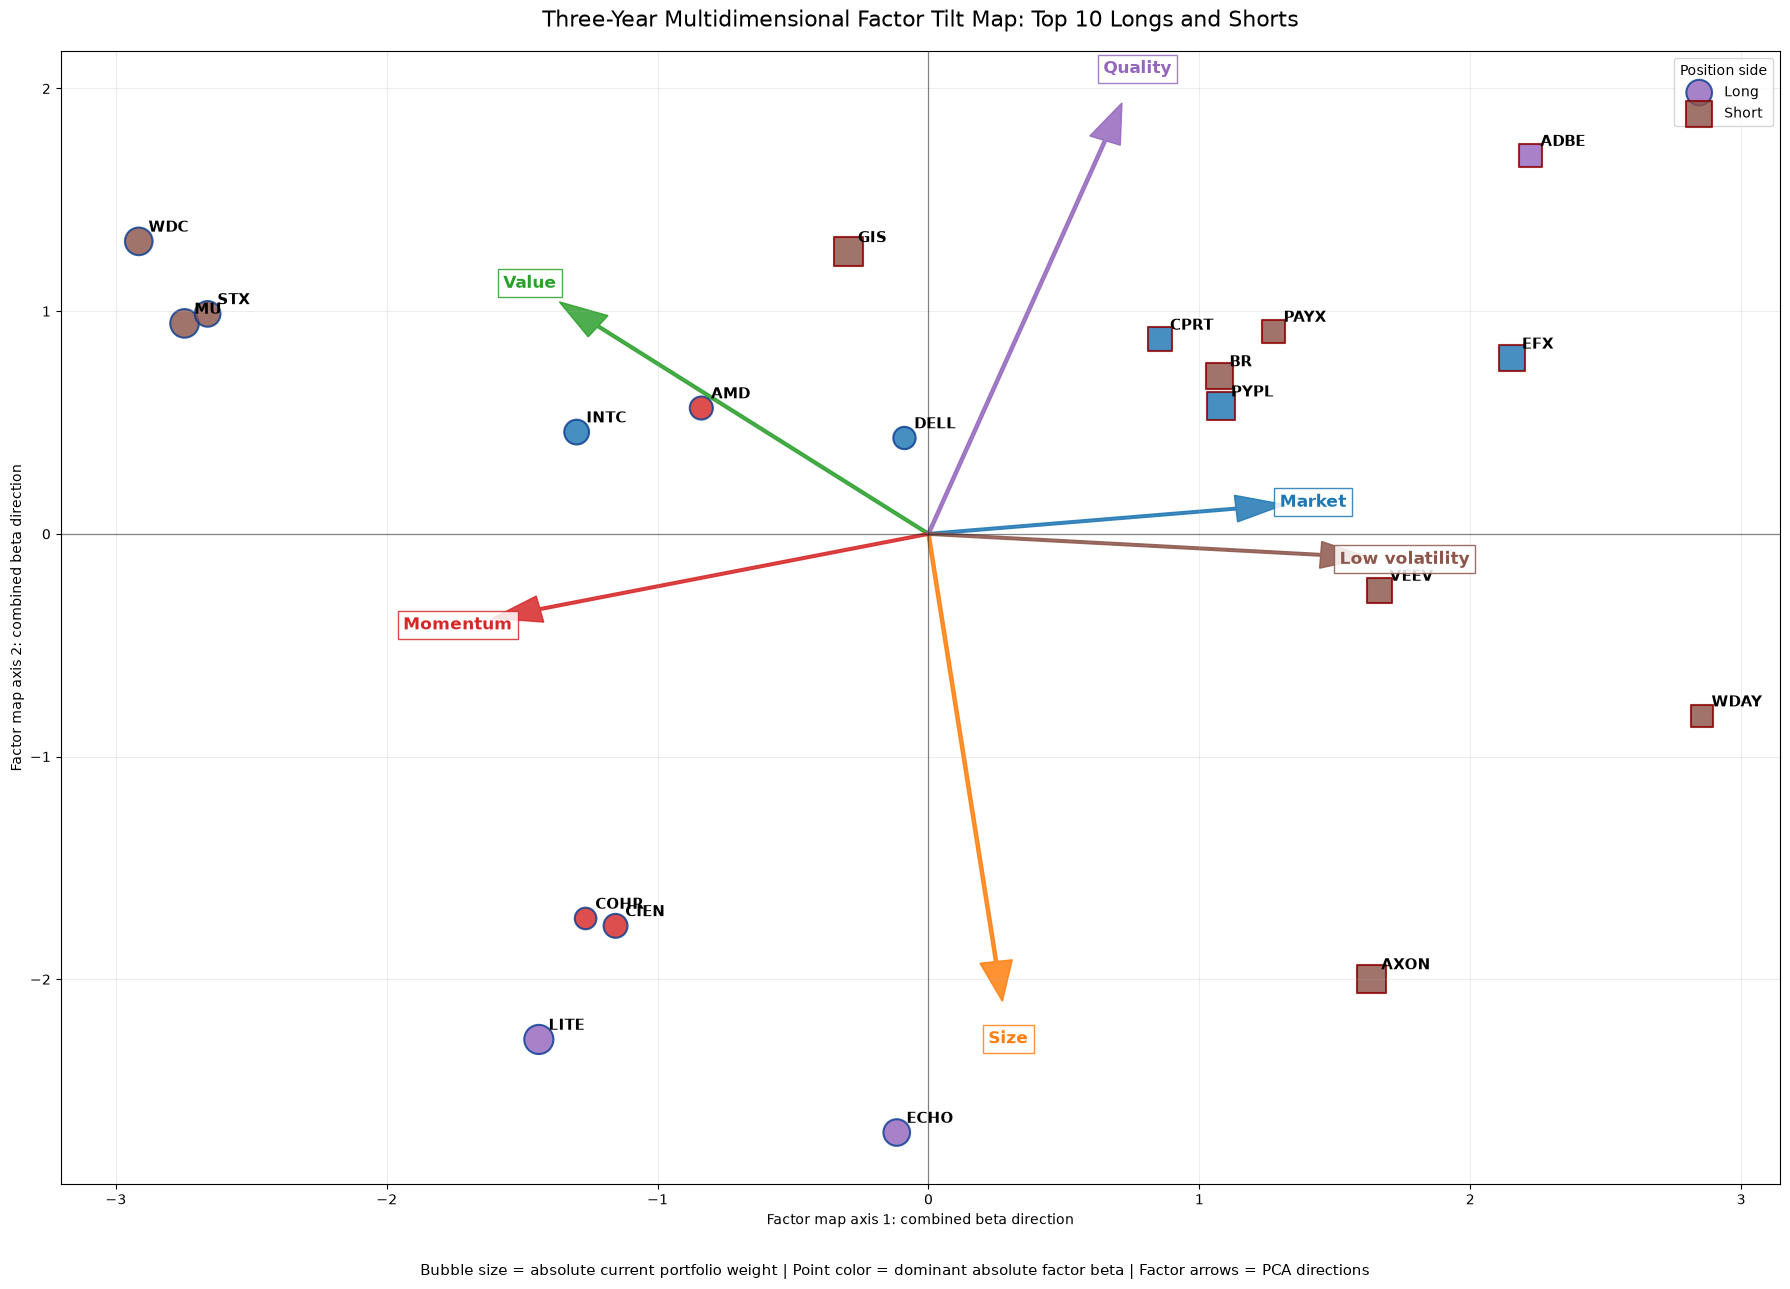

Factor tilt classification matrix:


,Side,Current weight,Dominant factor,Combined beta strength,Factor map axis 1,Factor map axis 2
Ticker,,,,,,
LITE,Long,+12.00%,Quality,6.922,-1.438,-2.270
MU,Long,+11.34%,Low volatility,6.313,-2.746,+0.945
WDC,Long,+10.21%,Low volatility,5.963,-2.915,+1.314
ECHO,Long,+9.15%,Quality,4.524,-0.117,-2.688
STX,Long,+8.17%,Low volatility,4.734,-2.661,+0.988
INTC,Long,+7.27%,Market,5.089,-1.299,+0.457
CIEN,Long,+6.43%,Momentum,5.401,-1.155,-1.760
AMD,Long,+5.66%,Momentum,4.221,-0.839,+0.565
DELL,Long,+4.95%,Market,3.414,-0.089,+0.431


Map reading guide: positions farther from the origin have stronger combined factor tilts; positions pointing in a factor-arrow direction are more associated with that factor. Use the original beta table for exact factor values.


In [18]:
# PCA factor map for the selected top long and short positions.
beta_columns = factor_names
beta_matrix = security_factor_beta_table[beta_columns].copy()
beta_matrix = beta_matrix.replace([np.inf, -np.inf], np.nan).dropna()

# Standardize each factor so one high-volatility proxy does not dominate the map.
beta_centered = beta_matrix - beta_matrix.mean(axis=0)
beta_scale = beta_centered.std(axis=0).replace(0, 1.0)
beta_standardized = beta_centered / beta_scale
u_values, singular_values, vt_values = np.linalg.svd(beta_standardized.to_numpy(), full_matrices=False)
security_coordinates = u_values[:, :2] * singular_values[:2]
security_coordinates = pd.DataFrame(
    security_coordinates,
    index=beta_standardized.index,
    columns=["Factor map axis 1", "Factor map axis 2"],
)

# Factor vectors in the same PCA coordinate system.
factor_vectors = vt_values[:2, :].T
vector_scale = max(
    security_coordinates.abs().max().max() / max(np.abs(factor_vectors).max(), 1e-12) * 0.72,
    1.0,
)
factor_vectors = factor_vectors * vector_scale

security_coordinates["Side"] = security_factor_beta_table.loc[security_coordinates.index, "Side"]
security_coordinates["Current weight"] = security_factor_beta_table.loc[security_coordinates.index, "Current weight"]
security_coordinates["Dominant factor"] = beta_matrix.abs().idxmax(axis=1)
security_coordinates["Combined beta strength"] = beta_matrix.abs().sum(axis=1)

factor_colors = {
    "Market": "#1f77b4",
    "Size": "#ff7f0e",
    "Value": "#2ca02c",
    "Momentum": "#d62728",
    "Quality": "#9467bd",
    "Low volatility": "#8c564b",
}

figure, axis = plt.subplots(figsize=(18, 13))
for side, marker, edge_color in [("Long", "o", "#0b3d91"), ("Short", "s", "#8b0000")]:
    subset = security_coordinates[security_coordinates["Side"] == side]
    axis.scatter(
        subset["Factor map axis 1"],
        subset["Factor map axis 2"],
        s=subset["Current weight"].abs() * 2600 + 130,
        c=[factor_colors[factor] for factor in subset["Dominant factor"]],
        marker=marker,
        alpha=0.82,
        edgecolor=edge_color,
        linewidth=1.5,
        label=side,
    )
    for ticker, row in subset.iterrows():
        axis.annotate(
            ticker,
            (row["Factor map axis 1"], row["Factor map axis 2"]),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=11,
            fontweight="bold",
        )

for factor_index, factor_name in enumerate(beta_columns):
    vector = factor_vectors[factor_index]
    axis.arrow(
        0,
        0,
        vector[0],
        vector[1],
        color=factor_colors[factor_name],
        width=0.012,
        head_width=0.12,
        length_includes_head=True,
        alpha=0.85,
    )
    axis.text(
        vector[0] * 1.08,
        vector[1] * 1.08,
        factor_name,
        color=factor_colors[factor_name],
        fontsize=12,
        fontweight="bold",
        ha="center",
        va="center",
        bbox={"facecolor": "white", "edgecolor": factor_colors[factor_name], "alpha": 0.85},
    )

axis.axhline(0, color="black", linewidth=0.9, alpha=0.45)
axis.axvline(0, color="black", linewidth=0.9, alpha=0.45)
axis.set_title("Three-Year Multidimensional Factor Tilt Map: Top 10 Longs and Shorts", fontsize=16, pad=18)
axis.set_xlabel("Factor map axis 1: combined beta direction")
axis.set_ylabel("Factor map axis 2: combined beta direction")
axis.grid(alpha=0.22)
axis.legend(title="Position side", loc="best")
figure.text(
    0.5,
    0.015,
    "Bubble size = absolute current portfolio weight | Point color = dominant absolute factor beta | Factor arrows = PCA directions",
    ha="center",
    fontsize=11,
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

print("Factor tilt classification matrix:")
display(security_coordinates[[
    "Side",
    "Current weight",
    "Dominant factor",
    "Combined beta strength",
    "Factor map axis 1",
    "Factor map axis 2",
]].sort_values(["Side", "Current weight"], ascending=[True, False]).style.format({
    "Current weight": "{:+.2%}",
    "Combined beta strength": "{:.3f}",
    "Factor map axis 1": "{:+.3f}",
    "Factor map axis 2": "{:+.3f}",
}))

print("Map reading guide: positions farther from the origin have stronger combined factor tilts; positions pointing in a factor-arrow direction are more associated with that factor. Use the original beta table for exact factor values.")